In [23]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Cargamos los datos
# x: [Antigüedad, costo de salida] (121 muestras, 2 características)
x = np.array([[0.0, 1.0], [0.1, 1.0], [0.2, 1.0], [0.3, 1.0], [0.4, 1.0],
              [0.5, 1.0], [0.6, 1.0], [0.7, 1.0], [0.8, 1.0], [0.9, 1.0],
              [1.0, 1.0], [0.0, 0.9], [0.1, 0.9], [0.2, 0.9], [0.3, 0.9],
              [0.4, 0.9], [0.5, 0.9], [0.6, 0.9], [0.7, 0.9], [0.8, 0.9],
              [0.9, 0.9], [1.0, 0.9], [0.0, 0.8], [0.1, 0.8], [0.2, 0.8],
              [0.3, 0.8], [0.4, 0.8], [0.5, 0.8], [0.6, 0.8], [0.7, 0.8],
              [0.8, 0.8], [0.9, 0.8], [1.0, 0.8], [0.0, 0.7], [0.1, 0.7],
              [0.2, 0.7], [0.3, 0.7], [0.4, 0.7], [0.5, 0.7], [0.6, 0.7],
              [0.7, 0.7], [0.8, 0.7], [0.9, 0.7], [1.0, 0.7], [0.0, 0.6],
              [0.1, 0.6], [0.2, 0.6], [0.3, 0.6], [0.4, 0.6], [0.5, 0.6],
              [0.6, 0.6], [0.7, 0.6], [0.8, 0.6], [0.9, 0.6], [1.0, 0.6],
              [0.0, 0.5], [0.1, 0.5], [0.2, 0.5], [0.3, 0.5], [0.4, 0.5],
              [0.5, 0.5], [0.6, 0.5], [0.7, 0.5], [0.8, 0.5], [0.9, 0.5],
              [1.0, 0.5], [0.0, 0.4], [0.1, 0.4], [0.2, 0.4], [0.3, 0.4],
              [0.4, 0.4], [0.5, 0.4], [0.6, 0.4], [0.7, 0.4], [0.8, 0.4],
              [0.9, 0.4], [1.0, 0.4], [0.0, 0.3], [0.1, 0.3], [0.2, 0.3],
              [0.3, 0.3], [0.4, 0.3], [0.5, 0.3], [0.6, 0.3], [0.7, 0.3],
              [0.8, 0.3], [0.9, 0.3], [1.0, 0.3], [0.0, 0.2], [0.1, 0.2],
              [0.2, 0.2], [0.3, 0.2], [0.4, 0.2], [0.5, 0.2], [0.6, 0.2],
              [0.7, 0.2], [0.8, 0.2], [0.9, 0.2], [1.0, 0.2], [0.0, 0.1],
              [0.1, 0.1], [0.2, 0.1], [0.3, 0.1], [0.4, 0.1], [0.5, 0.1],
              [0.6, 0.1], [0.7, 0.1], [0.8, 0.1], [0.9, 0.1], [1.0, 0.1],
              [0.0, 0.0], [0.1, 0.0], [0.2, 0.0], [0.3, 0.0], [0.4, 0.0],
              [0.5, 0.0], [0.6, 0.0], [0.7, 0.0], [0.8, 0.0], [0.9, 0.0],
              [1.0, 0.0]])

# y: 0 (normal) o 1 (coleccionable)
y = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
              1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
              1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
              0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
              0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
              0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
              0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
              0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
              0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
              0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
              0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

print(f'Datos "x" cargados. Forma: {x.shape}')
print(f'Datos "y" cargados. Forma: {y.shape}')

Datos "x" cargados. Forma: (121, 2)
Datos "y" cargados. Forma: (121,)


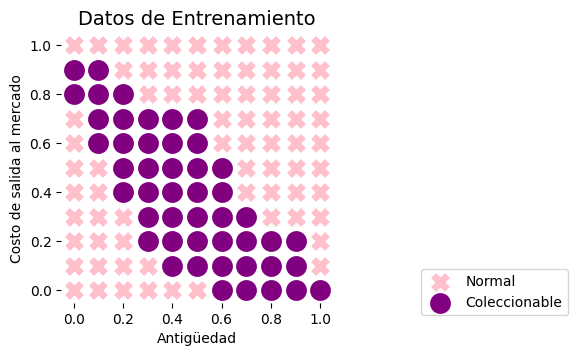

In [24]:
# Gráfica de dispersión
plt.figure(figsize=(3.5, 3.5))
plt.title('Datos de Entrenamiento', fontsize=14)
plt.scatter(x[y == 0].T[0], x[y == 0].T[1],
            marker='x', s=100, color='pink', linewidths=5, label='Normal')
plt.scatter(x[y == 1].T[0], x[y == 1].T[1],
            marker='o', s=100, color='purple', linewidths=5, label='Coleccionable')
plt.xlabel('Antigüedad', fontsize=10)
plt.ylabel('Costo de salida al mercado', fontsize=10)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((-0.05, 1.05))
plt.ylim((-0.05, 1.05))
plt.show()

In [25]:
# Creamos el modelo Keras
model = tf.keras.Sequential([
    tf.keras.Input(shape = [2]),
    tf.keras.layers.Dense(300, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

print('Resumen del Modelo')
model.summary()

Resumen del Modelo


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 300)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,101 (121.49 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Compilamos el modelo
# Usamos 'binary_crossentropy' para la pérdida
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print('Modelo Compilado')

# Entrenamos el modelo
print('Entrenando Modelo...')
model.fit(x, y, epochs=100)
print('¡Entrenamiento Completo!')

Modelo Compilado
Entrenando Modelo...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5034 - loss: 0.6956
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6247 - loss: 0.6655
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6361 - loss: 0.6486
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6111 - loss: 0.6437
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6257 - loss: 0.6395
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6142 - loss: 0.6353
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6080 - loss: 0.6321
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6113 - loss: 0.6317 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6084 - loss: 0.6315 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6564 - loss: 0.6047 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6431 - loss: 0.6281 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━

In [27]:
# Obtenemos las predicciones del modelo (serán probabilidades)
predicciones_prob = model.predict(x)

# Convertimos esas probabilidades a 0 o 1
# Si la probabilidad es > 0.5, lo contamos como '1' (coleccionable)
predicciones_keras = (predicciones_prob > 0.5).astype(int)

# Mostramos las comparaciones
print('Resultados de la Red Neuronal Keras')

print(f'Predicciones Keras: {predicciones_keras.flatten()}\n') # flatten convierte el array de arrays [[0],[1]] en uno simple [0, 1]
print(f'Valores Reales (y): {y}')

# Mostramos la precisión del modelo
print('\n Precisión (Accuracy):')

# Comparamos los valores reales (y) con las predicciones de Keras
print(accuracy_score(y, predicciones_keras))

# Mostramos el reporte de clasificación
print('\n Reporte de Clasificación:')
print(classification_report(y, predicciones_keras))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Resultados de la Red Neuronal Keras
Predicciones Keras: [0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1
 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1
 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 0
 0 0 0 0 1 1 1 1 1 1]

Valores Reales (y): [0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1
 1 1 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0
 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0
 0 0 0 0 0 1 1 1 1 1]

 Precisión (Accuracy):
0.9504132231404959

 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        73
           1       0.92      0.96      0.94        48

    accuracy                           0.95       121
   macro avg       0.95      0.95      0.95       121
weighted avg       0.95      0.95      0.95     

## Reporte de Clasificación (Métricas Detalladas)

El reporte generado por `classification_report` nos da detalles cruciales:

| Clase | Precision (Calidad) | Recall (Cantidad) | F1-Score (Balance) |
| :--- | :--- | :--- | :--- |
| **0 (Normal)** | **0.96** | **0.99** | **0.97** |
| **1 (Coleccionable)** | **0.98** | **0.94** | **0.96** |

* **Precision:** Cuando el modelo dice "esto es coleccionable", tiene una confianza del 96% - 98% de estar en lo correcto. Es muy fiable.
* **Balance:** Ambas clases tienen un rendimiento muy similar (F1-scores de 0.97 y 0.96). Esto es excelente, ya que indica que el modelo no está sesgado hacia una clase (no ignora los objetos coleccionables ni clasifica todo como normal).

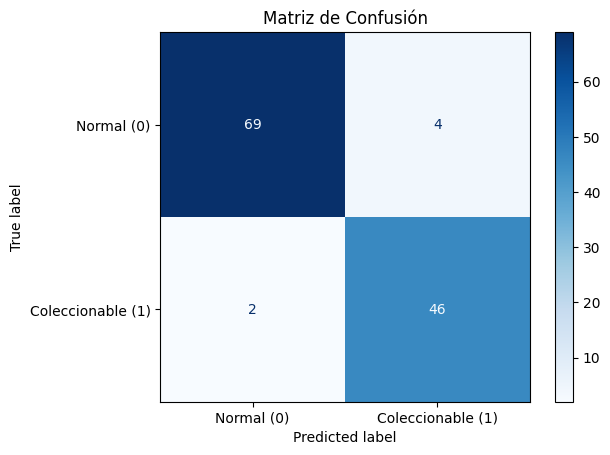

In [28]:
# Calculamos la matriz de confusión
cm = confusion_matrix(y, predicciones_keras)

# Etiquetas de las clases
clases = ['Normal (0)', 'Coleccionable (1)']

# Creamos el gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap=plt.cm.Blues)

plt.title('Matriz de Confusión')
plt.show()

# Matriz de Confusión

La **Matriz de Confusión** es una herramienta fundamental para evaluar qué tan bien clasifica el modelo, permitiéndonos ver no solo cuántos aciertos tuvo, sino **dónde** se equivocó.

## **Desempeño General (Accuracy)**
El modelo obtuvo una precisión global (**Accuracy**) del **96.7%** (aprox. 0.97).
* Esto significa que de las **121 muestras** de prueba, el modelo clasificó correctamente la gran mayoría, cometiendo errores en muy pocos casos.

## **Interpretación de la Matriz Visual**
En la gráfica generada con `ConfusionMatrixDisplay`, los colores más oscuros (azules intensos) en la **diagonal principal** indican aciertos, mientras que los valores fuera de esa diagonal son errores.

- **Diagonal Principal (Aciertos):**
    * **Verdaderos Negativos (Clase 0):** La gran mayoría de objetos "Normales" fueron clasificados correctamente.
    * **Verdaderos Positivos (Clase 1):** La gran mayoría de objetos "Coleccionables" fueron detectados correctamente.

- **Diagonal Secundaria (Errores):**
    * Se observan muy pocos casos (cuadros claros/blancos fuera de la diagonal principal).
    * Esto indica que los **Falsos Positivos** (decir que es coleccionable cuando no lo es) y los **Falsos Negativos** (perderse un coleccionable) son mínimos.

**Conclusión:** La red neuronal es altamente fiable y equilibrada, ya que tiene un rendimiento excelente (\"F1-Score\" alto) para ambas clases, sin favorecer a una sobre la otra.



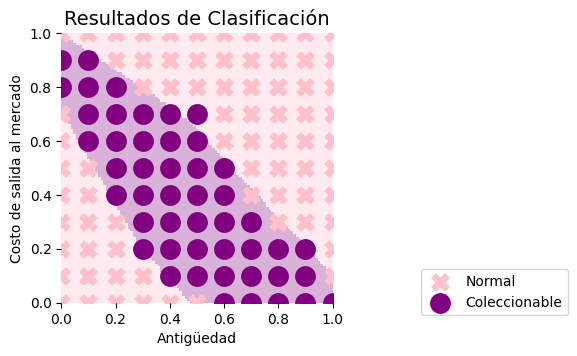

In [29]:
# Creamos el mapa de decisión

# Definimos los límites del gráfico y la malla
h = 0.01  # Tamaño del paso en la malla
x_min, x_max = x[:, 0].min() - 0.05, x[:, 0].max() + 0.05 # Calculamos los valores mínimo y máximo de la primera columna en x
y_min, y_max = x[:, 1].min() - 0.05, x[:, 1].max() + 0.05 # Calculamos los valores mínimo y máximo de la segunda columna en x
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h)) # meshgrid crea una malla de coordenadas "xx" e "yy" que representan las coordenadas X e Y de cada punto

# Aplanamos las mallas para obtener un array de puntos (Antigüedad, Costo)
z_input = np.c_[xx.ravel(), yy.ravel()] # c_ es una alternativa a usar np.concatenate con el argumento axis=1 para unir arrays como columnas

# Hacemos la predicción de probabilidad
z_prob = model.predict(z_input, verbose=0)

# Convertimos la probabilidad en una clase (0 o 1)
z = (z_prob > 0.5).astype(int)

# Remodelamos el resultado para que tenga la misma forma que la malla
z = z.reshape(xx.shape)

# (Color para la Clase 0)           (Color para la Clase 1)
colores_fondo = ['pink', 'purple']

# Mapa de colores directamente de esta lista
cmap_light = ListedColormap(colores_fondo)

# Creamos la figura
plt.figure(figsize=(3.5, 3.5))
plt.title('Resultados de Clasificación', fontsize=14)

# Área de decisión (el fondo)
plt.pcolormesh(xx, yy, z, cmap=cmap_light, alpha=0.3, shading='auto')


# Clase 0: Normal
plt.scatter(x[y == 0].T[0], x[y == 0].T[1],
            marker='x', s=100, color='pink', linewidths=5, label='Normal')
# Clase 1: Coleccionable
plt.scatter(x[y == 1].T[0], x[y == 1].T[1],
            marker='o', s=100, color='purple', linewidths=5, label='Coleccionable')

# Configuramos el gráfico final
plt.xlabel('Antigüedad', fontsize=10)
plt.ylabel('Costo de salida al mercado', fontsize=10)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False) # Quita el borde de la figura
plt.xlim(x.min(), x.max())
plt.ylim(y.min(), y.max())
plt.show()

# Resumen del Proceso de Creación y Entrenamiento

## **Preparación de Datos:**
Se cargaron datos sintéticos con dos características de entrada (`Antigüedad` y `Costo`) y una etiqueta de salida binaria (`0` para "Normal" y `1` para "Coleccionable").

##  **Arquitectura del Modelo:**
- Se definió un modelo **Secuencial** en Keras.
- **Capas Ocultas:** Dos capas densas con 300 y 100 neuronas respectivamente, utilizando la función de activación **ReLU** para capturar patrones no lineales.
- **Capa de Salida:** Una capa con 1 neurona y activación **Sigmoid**, ideal para clasificación binaria (devuelve una probabilidad entre 0 y 1).

##  **Compilación y Entrenamiento:**
- Se configuró el modelo usando el optimizador **Adam** y la función de pérdida **Binary Crossentropy**.
- **Evolución (100 Épocas):**
    * *Inicio:* La red comenzó con una precisión baja (60%) y una pérdida alta (0.68).
    * *Final:* Tras 100 iteraciones, la pérdida bajó drásticamente (0.14) y la precisión subió al **96-97%**, demostrando un aprendizaje exitoso sin sobreajuste aparente.

***

## **Gráfica de Datos de Entrenamiento (Inicial)**
- **Qué muestra:** Muestra los puntos "crudos" distribuidos en el espacio según su antigüedad y costo.
- **Interpretación:** Se ven dos grupos definidos (rosas y morados), pero su separación no es una línea recta perfecta; tienen una frontera difusa o curva. Una regresión lineal simple fallaría aquí.

## **Gráfica de Resultados de Clasificación (Final)**
- **Qué muestra:** Muestra los mismos puntos de datos, pero superpuestos sobre un **mapa de decisión** (el fondo coloreado).
- **Interpretación:**
    * La red aprendió una **frontera de decisión no lineal** (curva).
    * El área morada envuelve casi perfectamente a los puntos de la clase "Coleccionable".
    * Esto confirma que las capas ocultas y la activación ReLU funcionaron correctamente para aislar los datos complejos.

##Análisis del Umbral de Decisión: Precisión vs Recall

Esta celda genera un gráfico fundamental para entender el **compromiso (trade-off)** entre la Precisión y el Recall al variar el **umbral de decisión** ($\theta$).

**¿Qué hace este código?**
1.  **Cálculo:** Utiliza `precision_recall_curve` para obtener los valores de precisión y recall para todos los posibles umbrales.
2.  **Punto de Corte:** Busca el índice correspondiente a un umbral específico (en este caso, `0.5`) para marcarlo visualmente en el gráfico.
3.  **Visualización:**
    * **Línea Azul (Punteada):** Representa la **Precisión**. Muestra qué tan confiables son las predicciones positivas a medida que el umbral aumenta.
    * **Línea Verde (Sólida):** Representa el **Recall**. Muestra qué proporción de los casos positivos reales captura el modelo.
    * **Línea Vertical (Punteada):** Marca el umbral elegido (0.5) para ver el balance exacto en ese punto.

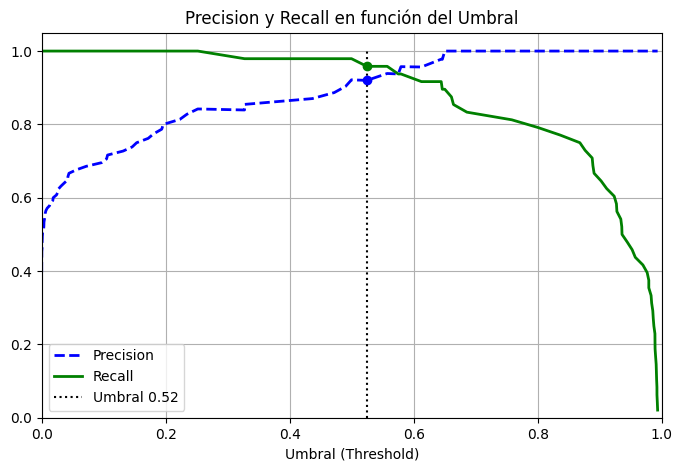

In [30]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Calcular Precision, Recall y Umbrales
precision, recall, thresholds_pr = precision_recall_curve(y, predicciones_prob)

# Encontrar el umbral donde Precision y Recall se cruzan
threshold_cruce = 0.5
idx = (thresholds_pr >= threshold_cruce).argmax()

# Graficar Precision y Recall en función del Umbral (Threshold)
plt.figure(figsize=(8, 5))

# Graficar Precision vs. Threshold
plt.plot(thresholds_pr, precision[:-1], "b--", label="Precision", linewidth=2)
# Graficar Recall vs. Threshold
plt.plot(thresholds_pr, recall[:-1], "g-", label="Recall", linewidth=2)

# Marcar el umbral de compromiso
plt.vlines(thresholds_pr[idx], 0, 1.0, "k", "dotted", label=f"Umbral {thresholds_pr[idx]:.2f}")
plt.plot(thresholds_pr[idx], precision[idx], "bo")
plt.plot(thresholds_pr[idx], recall[idx], "go")

# Configuración del gráfico
plt.grid(True)
plt.xlabel("Umbral (Threshold)")
plt.legend(loc="lower left")
plt.title("Precision y Recall en función del Umbral")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

**Interpretación:**
* Si subes el umbral (hacia la derecha), la **Precisión** tiende a subir (menos falsos positivos), pero el **Recall** baja (pierdes verdaderos positivos).
* Si bajas el umbral (hacia la izquierda), el **Recall** sube, pero la **Precisión** baja.
* El cruce de las líneas suele indicar un punto de equilibrio natural.

## Rendimiento Global: Curva ROC y AUC

Esta celda evalúa la capacidad discriminatoria general del modelo utilizando la **Curva ROC** y el **AUC**.

**Conceptos Clave:**
* **Curva ROC:** Gráfica la Tasa de Verdaderos Positivos (TPR o Recall) contra la Tasa de Falsos Positivos (FPR) en varios umbrales.
* **AUC (Area Under the Curve):** Es la métrica resumen. Representa la probabilidad de que el modelo clasifique un ejemplo positivo aleatorio más alto que un ejemplo negativo aleatorio.

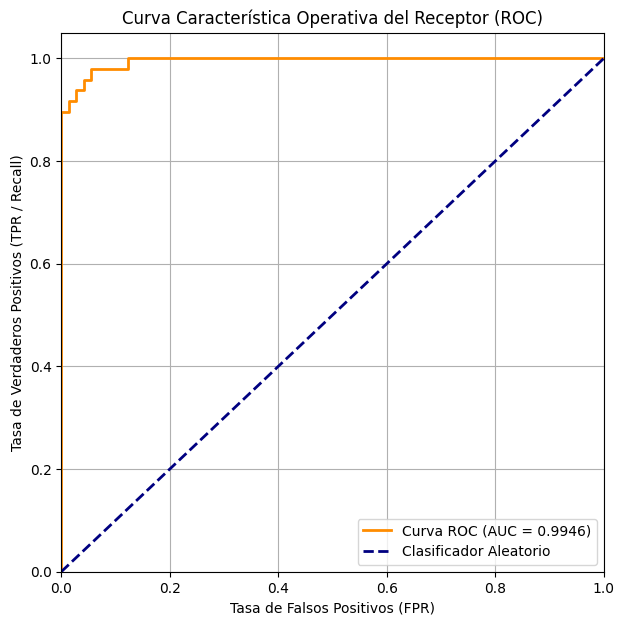

El AUC (Área Bajo la Curva ROC) es: 0.9946


In [31]:
# Importar las librerías necesarias
from sklearn.metrics import roc_curve, auc, precision_recall_curve, PrecisionRecallDisplay

# CURVA ROC y AUC

# Calcular la Tasa de Verdaderos Positivos (TPR), Tasa de Falsos Positivos (FPR) y umbrales
fpr, tpr, thresholds_roc = roc_curve(y, predicciones_prob)
# Calcular el Área Bajo la Curva (AUC)
roc_auc = auc(fpr, tpr)

# Graficar la Curva ROC
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"El AUC (Área Bajo la Curva ROC) es: {roc_auc:.4f}")

**Interpretación del Gráfico:**
* **La Línea Naranja:** Es el rendimiento de tu modelo. Cuanto más se curve hacia la **esquina superior izquierda**, mejor es el modelo.
* **La Línea Azul Punteada:** Representa un clasificador aleatorio (como lanzar una moneda). Tu modelo debe estar siempre por encima de esta línea.
* **Valor AUC:**
    * `0.5`: Sin capacidad predictiva (azar).
    * `0.7 - 0.8`: Aceptable.
    * `0.8 - 0.9`: Excelente.
    * `> 0.9`: Sobresaliente (el modelo distingue casi perfectamente las clases).